<a href="https://colab.research.google.com/github/guoqingoceanrs/OB.DAAC/blob/main/Access_oceancolor_data_with_earthaccess.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Access OB DAAC Ocean Color Data With Earthaccess

## Overview
This article demonstrates accessing and analyzing ocean color data using Python from the NASA OB DAAC archives. Currently, there are several ways to find and access ocean color data:
1. [NASA's Earthdata Search](https://search.earthdata.nasa.gov/search)
2. [NASA's CMR API](https://cmr.earthdata.nasa.gov/search/site/docs/search/api.html)
3. [OB.DAAC OPENDAP](https://oceandata.sci.gsfc.nasa.gov/opendap/)
4. [Ocean color file search](https://oceandata.sci.gsfc.nasa.gov/api/file_search_help)

## Dataset

The level 2 dataset of MODIS Aqua is one of the most popular datasets of OB.DAAC. Here we will use MODIS-Aqua L2 Chlorophyll data at Chesapeake Bay as an example to show how to access, download, visualize, and analyze the ocean color/Chlorophyll data in python using the `Earthaccess` python package through NASA Earthdata CMR API.

A demo of Earthaccess can be accessed [here](https://github.com/nsidc/earthaccess/blob/main/notebooks/Demo.ipynb).

The standard NASA ocean color Chlorophyll algorithm is described in the [Algorithm Theoretical Basis Document (ATBD)](https://www.earthdata.nasa.gov/apt/documents/chlor-a/v1.0).


## Requirements


1. **Earthdata Login**. An Earthdata Login account is required to access data from the NASA Earthdata system, including NASA ocean color data. To obtain access, please visit https://urs.earthdata.nasa.gov to register and manage your Earthdata Login account. Creating this account is free and only takes a moment to set up.
2. **Additional Requirements**: This tutorial requires the following Python modules installed in your system: `earthaccess`. To install the necessary Python modules, you can run:

> `!pip install earthaccess`

In [ ]:
#!pip install earthaccess

In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
import earthaccess
import netCDF4   as nc
import xarray as xr
import cmocean
import os
import numpy as np
import matplotlib.pyplot as plt
from pprint import pprint
import cartopy
import cartopy.crs as ccrs
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

## **1. Authentication**

Access to NASA ocean color data requires NASA Earthdata authentication. Here, we authenticate our Earthdata Login (EDL) information credentials stored in a .netrc file using the earthaccess python library: earthaccess.login(). This function will prompt for your NASA Earthdata username and password to create a .netrc file if one does not exist. It then uses your account information for authentication purposes.

In [ ]:
earthaccess.login(persist=True)

Enter your Earthdata Login username: guoqingw
Enter your Earthdata password: ··········
Persisting credentials to .netrc


## **2. Search for MODIS-Aqua Collections**

MODIS-Aqua level 1 - level 4 ocean color data products are hosted by the Ocean Biology Distributed Active Archive Center (OB DAAC). In this example, we will use the standard Chlorophyll a data from level 2 ocean color files. To find data we will use the `earthaccess` Python library. `earthaccess` searches NASA's Common Metadata Repository (CMR), a metadata system that catalogs Earth Science data and associated metadata records.

`collection_query` from `earthaccess` is used to search for the NASA data collections. Various query parameters can be used to search collections and granules using attributes associated to them in the metadata. See more details [here](https://github.com/nsidc/earthaccess/blob/main/notebooks/Demo.ipynb). Below, CMR Catalog are searched to find collections with **ocean color** keyword in them, managed by **OBDAAC**. The returned response can be used to retrieve the `concept-id` for each dataset.

In [ ]:
Query = earthaccess.collection_query().keyword('ocean color').bounding_box(-76.75,36.97,-75.74,39.01)

print(f'Collections found: {Query.hits()}')

# filtering what UMM fields to print, to see the full record we omit the fields filters
# meta is always included as
collections = Query.fields(['ShortName','Abstract']).get(3)
# Inspect 3 results printing just the ShortName and Abstract
collections[0:3]

Collections found: 354


[{
   "meta": {
     "concept-id": "C1240264615-OB_DAAC",
     "granule-count": 0,
     "provider-id": "OB_DAAC"
   },
   "umm": {
     "ShortName": "GOCI_L2_OC",
     "Abstract": "The Geostationary Ocean Color Imager (GOCI) is one of the three payloads onboard the Communication,Ocean and Meteorological Satellite (COMS). It acquires data in 8 spectral bands (6 visible, 2 NIR) witha spatial resolution of about 500m over the Korean sea. The ocean data products that can be derivedfrom the measurements are mainly the chlorophyll concentration, the optical diffuse attenuationcoefficients, the concentration of dissolved organic material or yellow substance, and the concentrationof suspended particles in the near-surface zone of the sea. In operational oceanography, satellite deriveddata products are used in conjunction with numerical models and in situ measurements to provide forecastingand now casting of the ocean state. Such information is of genuine interest for many categories of users."

In [ ]:
# We can now search for collections hosted by OBDAAC.
Query = earthaccess.collection_query().daac("OBDAAC")

print(f'Collections found: {Query.hits()}')
collections = Query.fields(['ShortName']).get(20)
# Printing 3 collections
collections[0:3]

Collections found: 702


[{
   "meta": {
     "concept-id": "C1633360083-OB_DAAC",
     "granule-count": 71,
     "provider-id": "OB_DAAC"
   },
   "umm": {
     "ShortName": "2009oct_Chesapeake"
   }
 },
 {
   "meta": {
     "concept-id": "C1633360084-OB_DAAC",
     "granule-count": 2,
     "provider-id": "OB_DAAC"
   },
   "umm": {
     "ShortName": "AAOT"
   }
 },
 {
   "meta": {
     "concept-id": "C1633360090-OB_DAAC",
     "granule-count": 1,
     "provider-id": "OB_DAAC"
   },
   "umm": {
     "ShortName": "ACE"
   }
 }]

In [ ]:
# Printing the concept-id for the first 10 collections
[collection.concept_id() for collection in collections[0:10]]

['C1633360083-OB_DAAC',
 'C1633360084-OB_DAAC',
 'C1633360090-OB_DAAC',
 'C1633360087-OB_DAAC',
 'C1633360089-OB_DAAC',
 'C1633360091-OB_DAAC',
 'C2108358203-OB_DAAC',
 'C1633360095-OB_DAAC',
 'C1633360097-OB_DAAC',
 'C1633360098-OB_DAAC']

## **3. Search for granules based on spatiotemporal criteria**
In this example we're querying for grnaules from MODIS-Aqua Level 2 Ocean color dataset (with the `short_name` of `"MODISA_L2_OC"`).

Using spatial and temporal arguments to search for granules covering Chesapeake Bay during the time frame of Oct 15 - 23, 2010.**bold text**

In [ ]:
Query = earthaccess.granule_query().short_name("MODISA_L2_OC").temporal("2010-10-15", "2010-10-23").bounding_box(-76.75,36.97,-75.74,39.01)
# check the number of granules found
print(f"Granules found: {Query.hits()}")

Granules found: 10


In [ ]:
# preview the data granules
granules

[Collection: {'ShortName': 'MODISA_L2_OC', 'Version': 'R2022.0'}
 Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'GPolygons': [{'Boundary': {'Points': [{'Latitude': 52.34512, 'Longitude': -66.87651}, {'Latitude': 47.74208, 'Longitude': -99.08517}, {'Latitude': 30.84857, 'Longitude': -89.69359}, {'Latitude': 34.35015, 'Longitude': -65.17007}, {'Latitude': 52.34512, 'Longitude': -66.87651}]}}]}}}
 Temporal coverage: {'RangeDateTime': {'EndingDateTime': '2010-10-15T18:29:59Z', 'BeginningDateTime': '2010-10-15T18:25:01Z'}}
 Size(MB): 33.93597602844238
 Data: ['https://oceandata.sci.gsfc.nasa.gov/cmr/getfile/AQUA_MODIS.20101015T182501.L2.OC.nc'],
 Collection: {'Version': 'R2022.0', 'ShortName': 'MODISA_L2_OC'}
 Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'GPolygons': [{'Boundary': {'Points': [{'Latitude': 54.5216, 'Longitude': -53.08418}, {'Latitude': 49.70603, 'Longitude': -86.76155}, {'Latitude': 32.94241, 'Longitude': -76.6796}, {'Latitude': 36.53275, 'Longit

In [ ]:
# Now we can print some info about these granules using the built-in methods
granules = Query.get(4)
data_links = [{'links': g.data_links(), 'size (MB):': g.size()} for g in granules]
data_links

[{'links': ['https://oceandata.sci.gsfc.nasa.gov/cmr/getfile/AQUA_MODIS.20101015T182501.L2.OC.nc'],
  'size (MB):': 33.93597602844238},
 {'links': ['https://oceandata.sci.gsfc.nasa.gov/cmr/getfile/AQUA_MODIS.20101016T173000.L2.OC.nc'],
  'size (MB):': 34.53151321411133},
 {'links': ['https://oceandata.sci.gsfc.nasa.gov/cmr/getfile/AQUA_MODIS.20101016T190501.L2.OC.nc'],
  'size (MB):': 49.9454870223999},
 {'links': ['https://oceandata.sci.gsfc.nasa.gov/cmr/getfile/AQUA_MODIS.20101017T181000.L2.OC.nc'],
  'size (MB):': 60.59778594970703}]

In [ ]:
# To check whether this granule belongs to a cloud-based collection
granules[0].cloud_hosted

False

## **4. Download, and visulize data**

This section demonstrates the downloading and visualization of Chlorophyll maps and Rrs spectra.
To find the cloud-free granules, the [L1/L2 browser](https://oceancolor.gsfc.nasa.gov/cgi/browse.pl?sen=amod) on [oceancolor website](https://oceancolor.gsfc.nasa.gov/) were used.

In [ ]:
# download the cloud-free file
files = earthaccess.download(granules[3], "data")

 Getting 1 granules, approx download size: 0.06 GB


QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
# Open the datasets with xarray
filename = '/content/data/AQUA_MODIS.20101017T181000.L2.OC.nc'
ds = xr.open_dataset(filename)
# Load attributes
ds_geo = xr.open_dataset(filename, group='geophysical_data')
ds_nav = xr.open_dataset(filename, group='navigation_data')

# Use .data_vars to find variable names
# ds['navigation_data'].data_vars
# ds['geophysical_data'].data_vars

# Read chlor_a, latitude, and longitude data from their respective groups
lat = ds_nav.latitude
lon = ds_nav.longitude
chlor_a = ds_geo.chlor_a
chlor = np.log10(chlor_a)

Text(0.5, 1.0, '2010-10-17T18:10:00.550Z')

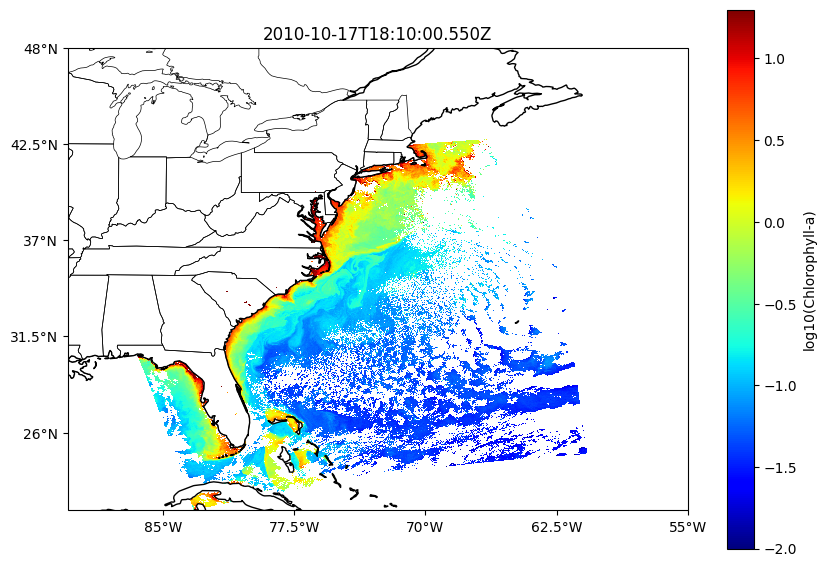

In [ ]:
# Plot Chlor_a data
fig = plt.figure(figsize=(10, 7))
map_projection = cartopy.crs.PlateCarree()
ax = plt.axes(projection=map_projection)

im = ax.pcolormesh(lon, lat,np.squeeze(chlor),cmap = 'jet', vmin=-2, vmax=1.3)
ax.coastlines()
ax.add_feature(cartopy.feature.STATES, linewidth=0.5)

ax.set_xticks(np.linspace(-85, -55, 5), crs=map_projection)
ax.set_yticks(np.linspace(26, 48, 5), crs=map_projection)
lon_formatter = LongitudeFormatter(zero_direction_label=True)
lat_formatter = LatitudeFormatter()
ax.xaxis.set_major_formatter(lon_formatter)
ax.yaxis.set_major_formatter(lat_formatter)

plt.colorbar(im, label='log10(Chlorophyll-a)')
plt.title(ds.time_coverage_start)

Text(0, 0.5, 'R$_{rs}$ (sr$^{-1}$)')

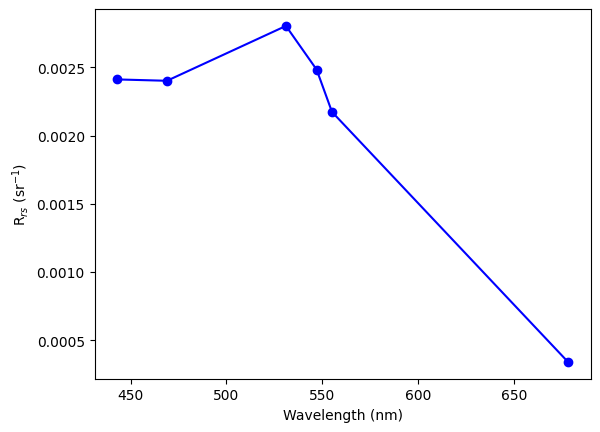

In [ ]:
# plot a sample Rrs spectra at a particular location, such as at Lat/Lon: 36.6N,74.8W
lat0 = 36.6 # lat
lon0 = -74.8 # lon

# read Rrs data
ds_band = xr.open_dataset(filename, group='sensor_band_parameters')
wav = ds_band.wavelength[[1,2,4,5,6,9]].values

Rrs412 = ds_geo.Rrs_412.values
Rrs443 = ds_geo.Rrs_443.values
Rrs488 = ds_geo.Rrs_488.values
Rrs531 = ds_geo.Rrs_531.values
Rrs547 = ds_geo.Rrs_547.values
Rrs667 = ds_geo.Rrs_667.values

Rrs = np.stack((Rrs412,Rrs443,Rrs488,Rrs531,Rrs547,Rrs667),axis=0)

# read Lat/Lon info
lon = ds_nav.longitude.values
lat = ds_nav.latitude.values

a = np.sqrt((lat - lat0)**2 + (lon - lon0)**2)

[i,j] = np.where(a == a.min())

Rrs0 = (Rrs[:,i,j])

# show the corresponding Rrs443, and Rrs values at that location
# print(Rrs443[idx])
# print(Rrs0)

# plot the Rrs spectrum
plt.plot(wav, Rrs0,'bo-',)

plt.xlabel('Wavelength (nm)')
plt.ylabel('R$_{rs}$ (sr$^{-1}$)')